In [8]:
!pip install torch_geometric
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import math
import matplotlib.pyplot as plt
import time

In [9]:
!git clone https://github.com/ananyabatra04/fairness-graph-gnn.git

fatal: destination path 'fairness-graph-gnn' already exists and is not an empty directory.


In [10]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

def load_pokec_data():
    print("Loading Pokec Data...")
    nodes = pd.read_csv("fairness-graph-gnn/dataset/pokec/region_job.csv")

    # Drop unknown labels
    nodes = nodes[nodes["I_am_working_in_field"] != -1]
    nodes["label"] = (nodes["I_am_working_in_field"] > 0).astype(int)

    feature_cols = [c for c in nodes.columns if c not in ["user_id", "region", "I_am_working_in_field", "label"]]

    X_raw = nodes[feature_cols].values
    X = torch.tensor(StandardScaler().fit_transform(X_raw), dtype=torch.float)
    y = torch.tensor(nodes["label"].values, dtype=torch.long)
    sensitive = torch.tensor((nodes["region"] == "Bratislava").astype(int).values, dtype=torch.long)

    edges = pd.read_csv("fairness-graph-gnn/dataset/pokec/region_job_relationship.txt", sep="\t", names=["src", "dst"])
    id_map = {uid: i for i, uid in enumerate(nodes["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges["src"], edges["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src])
            dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    return X, edge_index, y, sensitive


def load_nba_data():
    print("Loading NBA Data...")
    # Update this path to match your folder structure from the screenshot
    nodes = pd.read_csv("fairness-graph-gnn/dataset/NBA/nba.csv")

    # ⚠️ IMPORTANT: Check your nba.csv file to confirm these column names!
    # Standard FairGNN usually uses 'SALARY' and 'country'
    label_col = "SALARY"
    sens_col = "country"

    feature_cols = [c for c in nodes.columns if c not in ["user_id", label_col, sens_col]]

    X_raw = nodes[feature_cols].values
    X = torch.tensor(StandardScaler().fit_transform(X_raw), dtype=torch.float)
    y = torch.tensor(nodes[label_col].values, dtype=torch.long)
    sensitive = torch.tensor(nodes[sens_col].values, dtype=torch.long)

    # Update this path as well
    edges = pd.read_csv("fairness-graph-gnn/dataset/NBA/nba_relationship.txt", sep="\t", names=["src", "dst"])
    id_map = {uid: i for i, uid in enumerate(nodes["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges["src"], edges["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src])
            dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    return X, edge_index, y, sensitive

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score
import copy

class FairGNN_Args:
    def __init__(self, alpha=4.0, beta=0.01, lr=0.001, weight_decay=1e-5,
                 num_hidden=64, dropout=0.5, acc_thresh=0.0, roc_thresh=0.0):
        self.alpha = alpha
        self.beta = beta
        self.lr = lr
        self.weight_decay = weight_decay
        self.num_hidden = num_hidden
        self.dropout = dropout
        self.acc_thresh = acc_thresh
        self.roc_thresh = roc_thresh


# Same encoder from FairGNN paper code
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Exact FairGNN Architecture - taken from paper code
class FairGNN_Original(nn.Module):
    def __init__(self, nfeat, args):
        super(FairGNN_Original, self).__init__()
        self.args = args
        nhid = args.num_hidden
        dropout = args.dropout

        self.estimator = GCNEncoder(nfeat, nhid, 1, dropout)
        self.GNN = GCNEncoder(nfeat, nhid, nhid, dropout)
        self.classifier = nn.Linear(nhid, 1)
        self.adv = nn.Linear(nhid, 1)

        G_params = list(self.GNN.parameters()) + list(self.classifier.parameters()) + list(self.estimator.parameters())
        self.optimizer_G = torch.optim.Adam(G_params, lr=args.lr, weight_decay=args.weight_decay)
        self.optimizer_A = torch.optim.Adam(self.adv.parameters(), lr=args.lr, weight_decay=args.weight_decay)

        self.criterion = nn.BCEWithLogitsLoss()

        self.G_loss = 0
        self.A_loss = 0
        self.cov = 0
        self.cls_loss = 0
        self.adv_loss = 0

    def forward(self, x, edge_index):
        s = self.estimator(x, edge_index)
        z = self.GNN(x, edge_index)
        y = self.classifier(z)
        return y, s

    def optimize(self, x, edge_index, labels, idx_train, sens, idx_sens_train):
        self.train()

       # Update step
        self.adv.requires_grad_(False)
        self.optimizer_G.zero_grad()

        s = self.estimator(x, edge_index)
        h = self.GNN(x, edge_index)
        y = self.classifier(h)
        s_g = self.adv(h)

        s_score = torch.sigmoid(s.detach())
        s_score[idx_sens_train] = sens[idx_sens_train].unsqueeze(1).float()
        y_score = torch.sigmoid(y)

        self.cov = torch.abs(torch.mean((s_score - torch.mean(s_score)) * (y_score - torch.mean(y_score))))

        self.cls_loss = self.criterion(y[idx_train], labels[idx_train].unsqueeze(1).float())
        self.adv_loss = self.criterion(s_g, s_score)

        self.G_loss = self.cls_loss + self.args.alpha * self.cov - self.args.beta * self.adv_loss
        self.G_loss.backward()
        self.optimizer_G.step()


        self.adv.requires_grad_(True)
        self.optimizer_A.zero_grad()

        s_g = self.adv(h.detach())
        self.A_loss = self.criterion(s_g, s_score)
        self.A_loss.backward()
        self.optimizer_A.step()

# Training
def train_fairgnn_original(data, args, epochs=200):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data = data.to(device)
    model = FairGNN_Original(nfeat=data.num_features, args=args).to(device)

    idx_train = data.train_mask.nonzero(as_tuple=True)[0]
    idx_val = data.val_mask.nonzero(as_tuple=True)[0]
    idx_test = data.test_mask.nonzero(as_tuple=True)[0]

    idx_sens_train = idx_train

    best_result = {}
    best_fair = 100.0
    best_state = None

    for epoch in range(epochs):
        model.optimize(data.x, data.edge_index, data.y, idx_train, data.sensitive, idx_sens_train)

        model.eval()
        with torch.no_grad():
            output, s = model(data.x, data.edge_index)

            pred_y_val = (output[idx_val].squeeze() > 0).float()
            val_y = data.y[idx_val].float()
            acc_val = (pred_y_val == val_y).float().mean().item()

            try:
                roc_val = roc_auc_score(val_y.cpu().numpy(), output[idx_val].squeeze().cpu().numpy())
            except ValueError:
                roc_val = 0.5


            # Calculating Fairness Metrics
            sens_val = data.sensitive[idx_val]
            idx_s0_val = (sens_val == 0)
            idx_s1_val = (sens_val == 1)

            mean_s0 = pred_y_val[idx_s0_val].mean().item() if idx_s0_val.sum() > 0 else 0.0
            mean_s1 = pred_y_val[idx_s1_val].mean().item() if idx_s1_val.sum() > 0 else 0.0
            parity_val = abs(mean_s0 - mean_s1)


            if math.isnan(parity_val) or math.isnan(acc_val):
                parity_val = 1.0 # Forcing it to be a bad score instead of NaN

            pred_y_test = (output[idx_test].squeeze() > 0).float()
            acc_test = (pred_y_test == data.y[idx_test].float()).float().mean().item()
            sens_test = data.sensitive[idx_test]

            mean_s0_test = pred_y_test[(sens_test == 0)].mean().item() if (sens_test == 0).sum() > 0 else 0.0
            mean_s1_test = pred_y_test[(sens_test == 1)].mean().item() if (sens_test == 1).sum() > 0 else 0.0
            parity_test = abs(mean_s0_test - mean_s1_test)

            true_pos_mask_test = (data.y[idx_test] == 1)


            s0_true_pos_mask = (sens_test == 0) & true_pos_mask_test
            s1_true_pos_mask = (sens_test == 1) & true_pos_mask_test

            tpr_s0_test = pred_y_test[s0_true_pos_mask].mean().item() if s0_true_pos_mask.sum() > 0 else 0.0
            tpr_s1_test = pred_y_test[s1_true_pos_mask].mean().item() if s1_true_pos_mask.sum() > 0 else 0.0

            deo_test = abs(tpr_s0_test - tpr_s1_test)

            if acc_val > args.acc_thresh and roc_val > args.roc_thresh:
                if parity_val < best_fair:
                    best_fair = parity_val
                    best_state = copy.deepcopy(model.state_dict())
                    best_result = {
                        'epoch': epoch,
                        'acc': acc_test,
                        'parity': parity_test,
                        'deo': deo_test,
                    }

    if best_state is not None:
        model.load_state_dict(best_state)
    else:
        print("Warning: Model never reached Acc/ROC thresholds!")

    return best_result

In [12]:
# Datasets and sweeping over seeds and alphas
DATASETS = ["nba", "pokec",]
SEEDS = [42, 128, 512]
ALPHAS = [0, 0.5, 1.0, 5.0, 10.0]

all_results = []
output_file = "pyg_fairness_results_combined.csv"

for ds in DATASETS:
    if ds == "pokec":
        X, edge_index, y, sensitive = load_pokec_data()
        data = Data(x=X, edge_index=edge_index, y=y)
        data.sensitive = sensitive
        epochs = 1000
        current_acc_thresh = 0.65

    elif ds == "nba":
        X, edge_index, y, sensitive = load_nba_data()

        if y.max() > 1:
            print("Binarizing NBA salaries at the median...")
            y = (y > y.median()).to(torch.long)

        data = Data(x=X, edge_index=edge_index, y=y)
        data.sensitive = sensitive
        epochs = 200
        current_acc_thresh = 0.4

    num_nodes = data.num_nodes


    train_size = int(num_nodes * 0.70)
    val_size = int(num_nodes * 0.15)
    sens_train_size = int(train_size * 0.5)

    for a in ALPHAS:
        print(f"\nStarting Sweep: Dataset={ds}, Alpha={a}")
        current_group = []

        for s in SEEDS:
            print(f"Running Seed {s}...", end=" ", flush=True)
            start_time = time.time()

            np.random.seed(s)
            torch.manual_seed(s)

            indices = np.arange(num_nodes)
            np.random.shuffle(indices)

            val_size = int(num_nodes * 0.25)
            val_start = max(train_size, sens_train_size)

            train_idx = indices[:train_size]
            sens_train_idx = indices[:sens_train_size]
            val_idx = indices[val_start : val_start + val_size]
            test_idx = indices[val_start + val_size :]

            data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
            data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
            data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
            data.sens_train_mask = torch.zeros(num_nodes, dtype=torch.bool)

            data.train_mask[train_idx] = True
            data.sens_train_mask[sens_train_idx] = True
            data.val_mask[val_idx] = True
            data.test_mask[test_idx] = True

            current_beta = 0.01
            args = FairGNN_Args(alpha=a, beta=current_beta, acc_thresh=current_acc_thresh, roc_thresh=0.0)

            metrics = train_fairgnn_original(data, args, epochs=epochs)

            if metrics and "acc" in metrics:
                metrics.update({
                    "dataset": ds,
                    "alpha": a,
                    "seed": s,
                    "time_sec": time.time() - start_time
                })
                all_results.append(metrics)
                current_group.append(metrics)
                print(f"Done! ({metrics.get('acc', 0):.4f} Acc | {metrics.get('parity', 0):.4f} ΔSP | {metrics.get('deo', 0):.4f} ΔEO)")
            else:
                print("FAILED (Model didn't return valid metrics)")

        if current_group:
            accs = [r['acc'] for r in current_group]
            dsps = [r['parity'] for r in current_group]
            deos = [r.get('deo', 0) for r in current_group]

            print(f"Mean Alpha {a}: Acc={np.mean(accs):.4f} | ΔSP={np.mean(dsps):.4f} | ΔEO={np.mean(deos):.4f}")

if all_results:
    df = pd.DataFrame(all_results)
    df.to_csv(output_file, index=False)
    print(f"\nAll experiments complete. Results saved to {output_file}")
else:
    print("\nNo results were collected.")

Loading NBA Data...

Starting Sweep: Dataset=nba, Alpha=0
Running Seed 42... Done! (0.4762 Acc | 0.0000 ΔSP | 0.0000 ΔEO)
Running Seed 128... Done! (0.4286 Acc | 0.1765 ΔSP | 0.2000 ΔEO)
Running Seed 512... Done! (0.6190 Acc | 0.2857 ΔSP | 0.5714 ΔEO)
Mean Alpha 0: Acc=0.5079 | ΔSP=0.1541 | ΔEO=0.2571

Starting Sweep: Dataset=nba, Alpha=0.5
Running Seed 42... Done! (0.4762 Acc | 0.0000 ΔSP | 0.0000 ΔEO)
Running Seed 128... Done! (0.4286 Acc | 0.1765 ΔSP | 0.2000 ΔEO)
Running Seed 512... Done! (0.6190 Acc | 0.2857 ΔSP | 0.5714 ΔEO)
Mean Alpha 0.5: Acc=0.5079 | ΔSP=0.1541 | ΔEO=0.2571

Starting Sweep: Dataset=nba, Alpha=1.0
Running Seed 42... Done! (0.4762 Acc | 0.0000 ΔSP | 0.0000 ΔEO)
Running Seed 128... Done! (0.4286 Acc | 0.1765 ΔSP | 0.2000 ΔEO)
Running Seed 512... Done! (0.6190 Acc | 0.2857 ΔSP | 0.5714 ΔEO)
Mean Alpha 1.0: Acc=0.5079 | ΔSP=0.1541 | ΔEO=0.2571

Starting Sweep: Dataset=nba, Alpha=5.0
Running Seed 42... Done! (0.4762 Acc | 0.0000 ΔSP | 0.0000 ΔEO)
Running Seed 128...

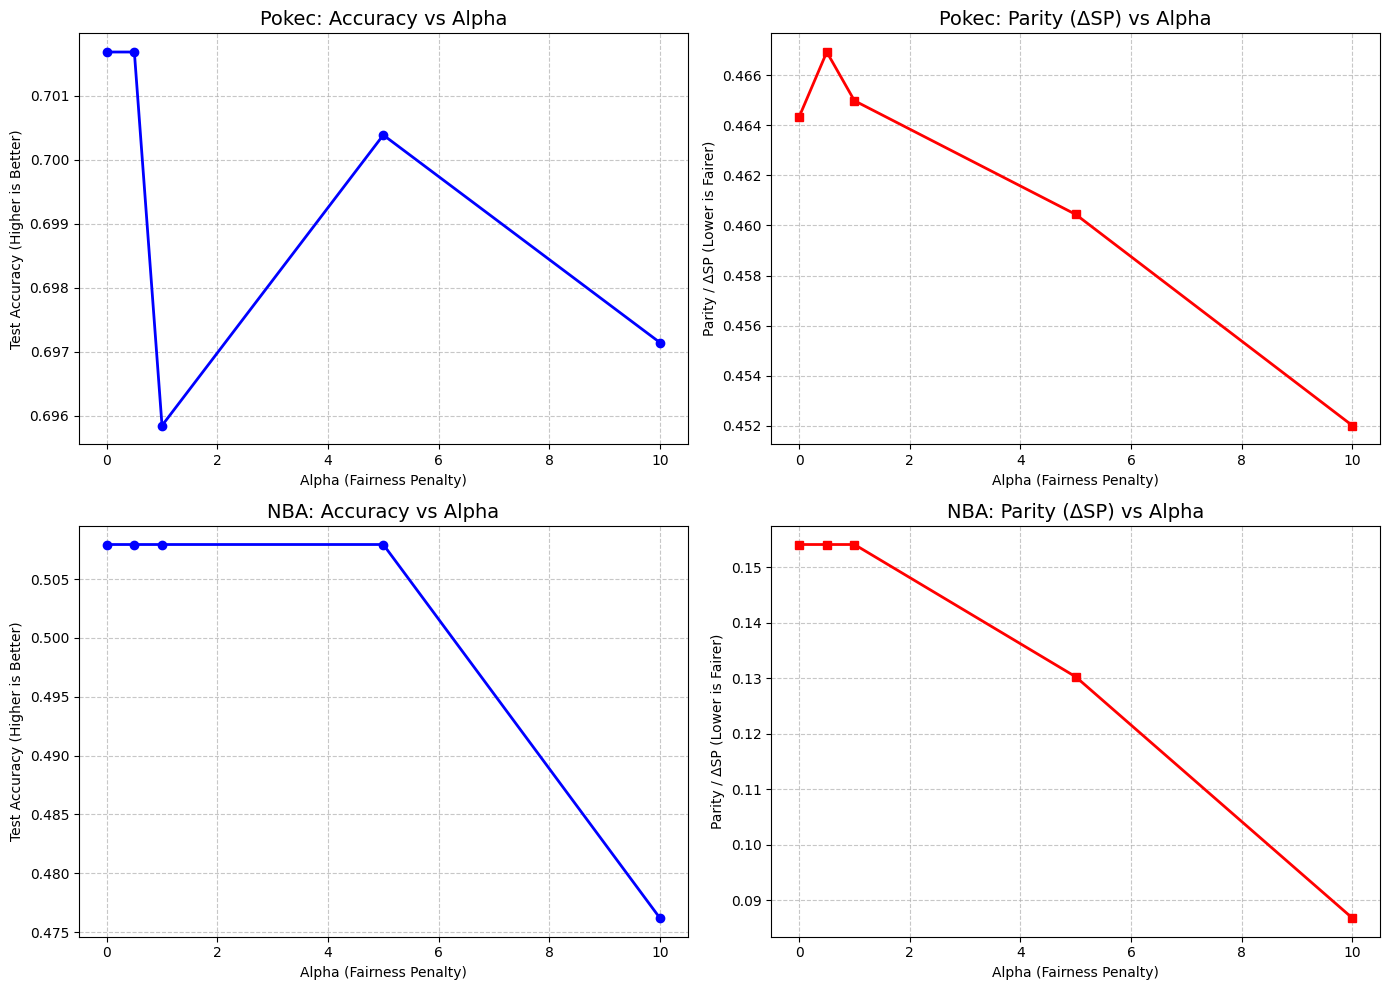

In [13]:
df = pd.read_csv("pyg_fairness_results_combined.csv")

summary = df.groupby(['dataset', 'alpha'])[['acc', 'parity']].mean().reset_index()

pokec_data = summary[summary['dataset'] == 'pokec']
nba_data = summary[summary['dataset'] == 'nba']

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
# --- Plot 1: Accuracy vs Alpha ---
ax1.plot(pokec_data['alpha'], pokec_data['acc'], marker='o', color='blue', linewidth=2)
ax1.set_title("Pokec: Accuracy vs Alpha", fontsize=14)
ax1.set_xlabel("Alpha (Fairness Penalty)")
ax1.set_ylabel("Test Accuracy (Higher is Better)")
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Parity (ΔSP) vs Alpha ---
ax2.plot(pokec_data['alpha'], pokec_data['parity'], marker='s', color='red', linewidth=2)
ax2.set_title("Pokec: Parity (ΔSP) vs Alpha", fontsize=14)
ax2.set_xlabel("Alpha (Fairness Penalty)")
ax2.set_ylabel("Parity / ΔSP (Lower is Fairer)")
ax2.grid(True, linestyle='--', alpha=0.7)

# --- Plot 1: Accuracy vs Alpha ---
ax3.plot(nba_data['alpha'], nba_data['acc'], marker='o', color='blue', linewidth=2)
ax3.set_title("NBA: Accuracy vs Alpha", fontsize=14)
ax3.set_xlabel("Alpha (Fairness Penalty)")
ax3.set_ylabel("Test Accuracy (Higher is Better)")
ax3.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Parity (ΔSP) vs Alpha ---
ax4.plot(nba_data['alpha'], nba_data['parity'], marker='s', color='red', linewidth=2)
ax4.set_title("NBA: Parity (ΔSP) vs Alpha", fontsize=14)
ax4.set_xlabel("Alpha (Fairness Penalty)")
ax4.set_ylabel("Parity / ΔSP (Lower is Fairer)")
ax4.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()